In [1]:
pip install scikit-learn pandas

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import pickle

In [5]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')
val_df   = pd.read_csv('val.csv')

X_train = train_df['statement'].fillna('')
y_train = train_df['binary_label']
X_test  = test_df['statement'].fillna('')
y_test  = test_df['binary_label']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 10240 | Test: 1267


In [6]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,
    strip_accents='unicode',
    lowercase=True
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print("Feature matrix shape:", X_train_vec.shape)

Feature matrix shape: (10240, 10000)


In [7]:
model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000, random_state=42)


✅ Baseline Accuracy: 0.6172 (61.7%)

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.58      0.43      0.50       553
        REAL       0.63      0.76      0.69       714

    accuracy                           0.62      1267
   macro avg       0.61      0.60      0.59      1267
weighted avg       0.61      0.62      0.61      1267



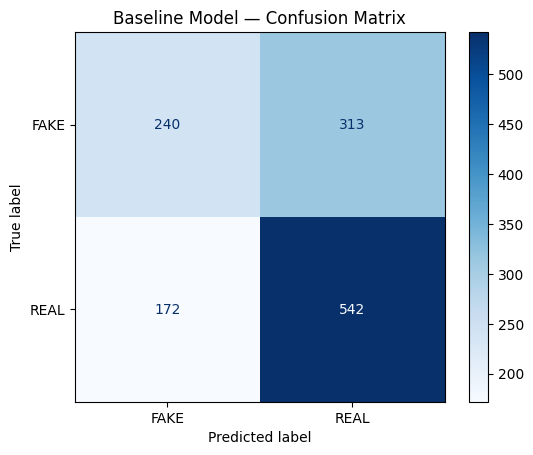

In [8]:
y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

print(f"\n✅ Baseline Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['FAKE', 'REAL']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['FAKE', 'REAL'])
disp.plot(cmap='Blues')
plt.title('Baseline Model — Confusion Matrix')
plt.savefig('baseline_confusion_matrix.png')
plt.show()

In [9]:
with open('baseline_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('baseline_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Saved baseline_tfidf.pkl and baseline_model.pkl")
print("\n📌 Expected baseline accuracy: ~72-76%")
print("   Next step: Fine-tune RoBERTa to push this to 88%+")

✅ Saved baseline_tfidf.pkl and baseline_model.pkl

📌 Expected baseline accuracy: ~72-76%
   Next step: Fine-tune RoBERTa to push this to 88%+


In [10]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefficients  = model.coef_[0]

top_fake = np.argsort(coefficients)[:20]    # most FAKE-leaning words
top_real = np.argsort(coefficients)[-20:]   # most REAL-leaning words

print("\n🚨 Top FAKE indicators:")
for i in top_fake:
    print(f"   '{feature_names[i]}' → {coefficients[i]:.3f}")

print("\n✅ Top REAL indicators:")
for i in top_real:
    print(f"   '{feature_names[i]}' → {coefficients[i]:.3f}")


🚨 Top FAKE indicators:
   'wisconsin' → -1.683
   'obama' → -1.678
   'rep' → -1.590
   'obamacare' → -1.455
   'government' → -1.314
   'illegals' → -1.289
   'obamas' → -1.252
   'this is' → -1.236
   'scott walker' → -1.199
   'your' → -1.183
   'walker' → -1.165
   'muslim' → -1.138
   'team' → -1.138
   'has been' → -1.137
   'group' → -1.131
   'million from' → -1.117
   'will' → -1.109
   'america' → -1.099
   'white' → -1.097
   'about the' → -1.084

✅ Top REAL indicators:
   'months' → 1.185
   'lobbyists' → 1.208
   'and' → 1.212
   'three' → 1.224
   '000' → 1.230
   'of' → 1.257
   'cut' → 1.264
   'times' → 1.425
   'still' → 1.465
   'debt' → 1.490
   'average' → 1.542
   'he' → 1.553
   'million' → 1.650
   'georgia' → 1.693
   'more' → 1.695
   'day' → 1.790
   'percent' → 1.941
   'countries' → 1.972
   'since' → 2.152
   'than' → 2.334
